In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2021, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #2879: 1510
Sim #1597: 1480
Sim #6974: 1470
Sim #7770: 1440
Sim #9986: 1440

BOTTOM 5 SCORES
Sim #8075: 130
Sim #779: 150
Sim #6330: 160
Sim #2875: 170
Sim #1026: 170

AVERAGE SCORE: 535.33


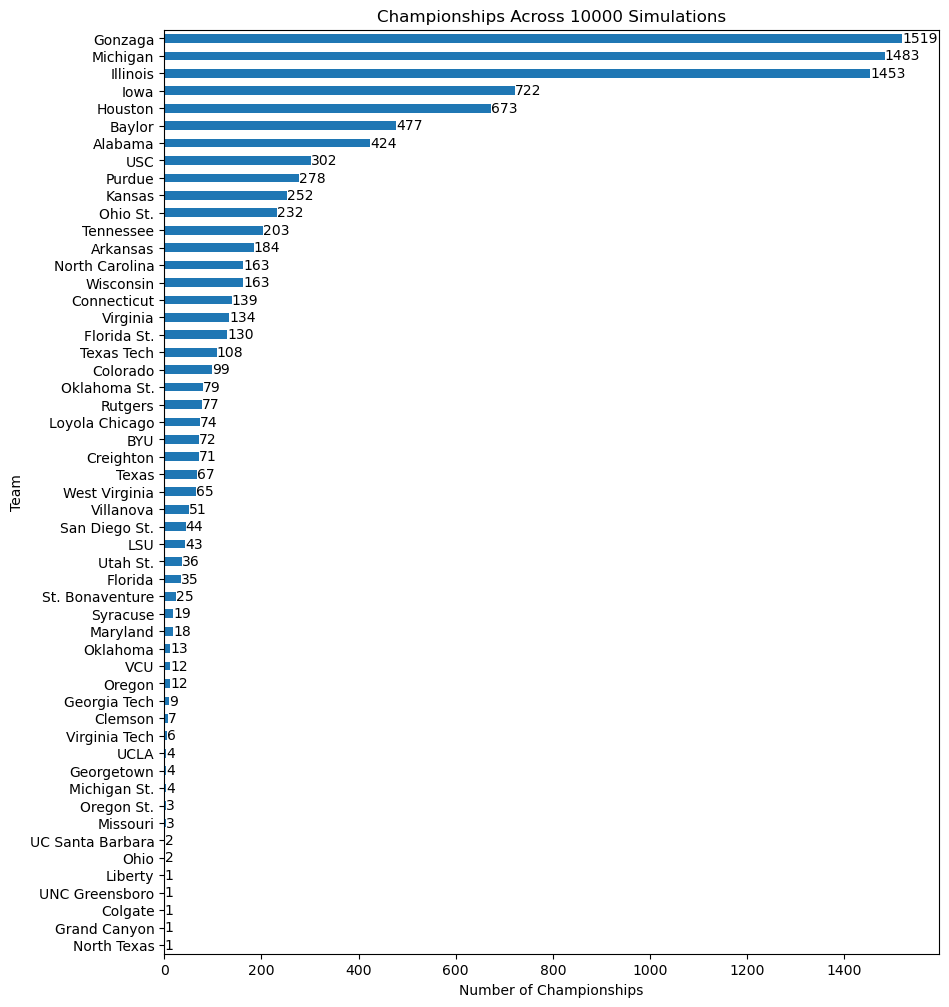

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Gonzaga           1519 --> 15.19%          BYU                72 --> 0.72%            UC Santa Barbara    2 --> 0.02%         
Michigan          1483 --> 14.83%          Creighton          71 --> 0.71%            Ohio                2 --> 0.02%         
Illinois          1453 --> 14.53%          Texas              67 --> 0.67%            Liberty             1 --> 0.01%         
Iowa              722 --> 7.22%            West Virginia      65 --> 0.65%            North Texas         1 --> 0.01%         
Houston           673 --> 6.73%            Villanova          51 --> 0.51%            UNC Greensboro      1 --> 0.01%         
Baylor            477 --> 4.77%            San Diego St.      44 --> 0.44%            Colgate             1 --> 0.01%         
Alabama           424 --> 4.24%            LSU                43 --> 0.43%            Grand Canyon        1 --> 0.01%         
USC               302 --> 3.02%            Utah St.           36 -

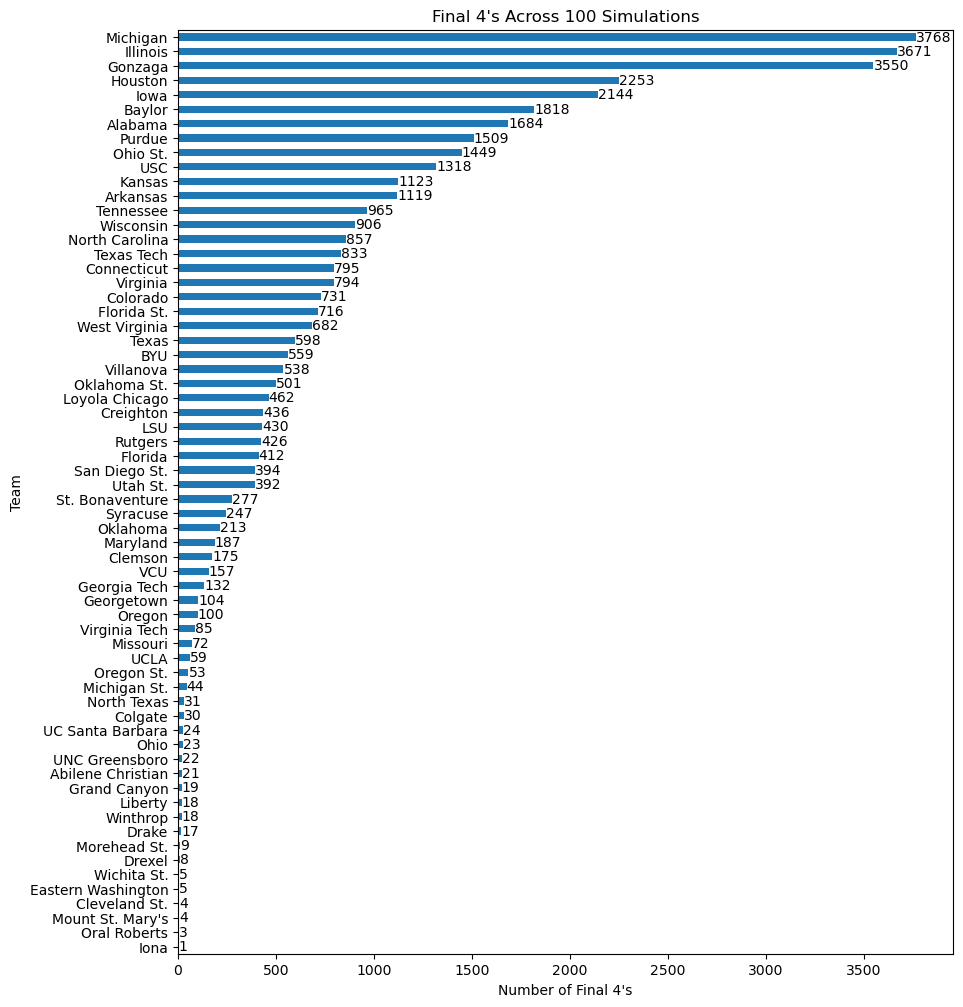

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Michigan          3768 --> 37.68%          Villanova         538 --> 5.38%            North Texas        31 --> 0.31%         
Illinois          3671 --> 36.71%          Oklahoma St.      501 --> 5.01%            Colgate            30 --> 0.3%          
Gonzaga           3550 --> 35.5%           Loyola Chicago    462 --> 4.62%            UC Santa Barbara   24 --> 0.24%         
Houston           2253 --> 22.53%          Creighton         436 --> 4.36%            Ohio               23 --> 0.23%         
Iowa              2144 --> 21.44%          LSU               430 --> 4.3%             UNC Greensboro     22 --> 0.22%         
Baylor            1818 --> 18.18%          Rutgers           426 --> 4.26%            Abilene Christian  21 --> 0.21%         
Alabama           1684 --> 16.84%          Florida           412 --> 4.12%            Grand Canyon       19 --> 0.19%         
Purdue            1509 --> 15.09%          San Diego St.     394 --> 3

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Gonzaga           5710 --> 57.1%           Rutgers           1210 --> 12.1%           Colgate           163 --> 1.63%         
Illinois          5269 --> 52.69%          Creighton         1207 --> 12.07%          North Texas       136 --> 1.36%         
Michigan          5020 --> 50.2%           Oklahoma St.      1193 --> 11.93%          Abilene Christian 124 --> 1.24%         
Houston           4223 --> 42.23%          San Diego St.     1168 --> 11.68%          UC Santa Barbara  119 --> 1.19%         
Iowa              3909 --> 39.09%          Villanova         1160 --> 11.6%           Ohio              110 --> 1.1%          
Alabama           3553 --> 35.53%          Florida           1143 --> 11.43%          UNC Greensboro    103 --> 1.03%         
Ohio St.          3080 --> 30.8%           Loyola Chicago    998 --> 9.98%            Grand Canyon       99 --> 0.99%         
Baylor            2812 --> 28.12%          Utah St.          987 --> 9

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Gonzaga           7384 --> 73.84%          Florida           3073 --> 30.73%          Ohio              648 --> 6.48%         
Illinois          6788 --> 67.88%          Connecticut       3031 --> 30.31%          Abilene Christian 631 --> 6.31%         
Michigan          6718 --> 67.18%          San Diego St.     2813 --> 28.13%          Michigan St.      627 --> 6.27%         
Iowa              6385 --> 63.85%          Wisconsin         2775 --> 27.75%          North Texas       601 --> 6.01%         
Houston           6007 --> 60.07%          North Carolina    2609 --> 26.09%          Liberty           579 --> 5.79%         
Purdue            5904 --> 59.04%          Rutgers           2330 --> 23.3%           Colgate           565 --> 5.65%         
Ohio St.          5615 --> 56.15%          Syracuse          2127 --> 21.27%          Grand Canyon      563 --> 5.63%         
Alabama           5376 --> 53.76%          Loyola Chicago    2031 -->

In [11]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
623086,9164,1.0,Drexel,16,0,5,100.000,N/A,10.310,Illinois,18.608,Georgia Tech,16.299,Oklahoma St.,11.896,Syracuse,18.783,Wisconsin,10.966,Virginia,0.006
97225,1430,4.0,Eastern Washington,14,0,5,100.000,N/A,15.980,Kansas,25.683,Drake,10.036,Iowa,9.873,Gonzaga,18.463,LSU,13.712,Baylor,0.006
470500,6920,1.0,Morehead St.,14,0,5,100.000,N/A,20.101,West Virginia,22.256,Syracuse,13.417,Houston,10.565,Illinois,14.407,Baylor,9.952,Michigan,0.008
654114,9620,2.0,North Texas,13,1,6,100.000,N/A,16.770,Purdue,31.525,Villanova,18.971,Wisconsin,19.676,Texas Tech,12.514,Illinois,37.617,Oregon,0.009
123412,1815,4.0,Ohio,13,1,5,100.000,N/A,22.558,Virginia,24.670,Creighton,11.247,Gonzaga,9.923,Iowa,19.936,Texas,22.699,North Carolina,0.010
275052,4045,4.0,Ohio,13,1,6,100.000,N/A,22.558,Virginia,24.670,Creighton,11.247,Gonzaga,37.267,VCU,20.014,Colorado,21.840,Texas Tech,0.010
68604,1009,4.0,Ohio,13,1,5,100.000,N/A,22.558,Virginia,24.670,Creighton,11.247,Gonzaga,9.923,Iowa,23.569,St. Bonaventure,12.811,Illinois,0.013
645159,9488,3.0,Michigan St.,11,0,6,51.064,UCLA,31.087,BYU,33.732,Texas,28.526,Alabama,15.493,Michigan,21.800,Gonzaga,25.168,Purdue,0.013
540932,7955,4.0,Ohio,13,1,6,100.000,N/A,22.558,Virginia,43.504,UC Santa Barbara,11.247,Gonzaga,48.796,Grand Canyon,18.253,Connecticut,12.811,Illinois,0.013
326000,4795,1.0,Morehead St.,14,0,5,100.000,N/A,20.101,West Virginia,22.256,Syracuse,13.417,Houston,17.993,Loyola Chicago,14.407,Baylor,9.952,Michigan,0.014


In [12]:
df[df["sim_num"] == 2879].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
195721,2879,2.0,Baylor,1,6,6,100.000,N/A,86.017,Hartford,49.804,North Carolina,67.630,Villanova,70.042,Florida,44.943,Houston,38.314,Gonzaga,3.494
195758,2879,4.0,Gonzaga,1,5,5,100.000,N/A,91.023,Norfolk St.,83.600,Missouri,79.316,Creighton,61.491,USC,56.140,Alabama,61.686,Baylor,7.983
195708,2879,1.0,Houston,2,4,4,100.000,N/A,88.630,Cleveland St.,65.631,Rutgers,70.575,West Virginia,64.055,Loyola Chicago,55.057,Baylor,0.000,N/A,11.818
195737,2879,3.0,Alabama,2,2,4,100.000,N/A,88.107,Iona,70.673,Maryland,64.847,Texas,33.065,Michigan,43.860,Gonzaga,0.000,N/A,7.496
195746,2879,3.0,Michigan,1,3,3,100.000,N/A,89.871,Mount St. Mary's,68.037,LSU,74.363,Florida St.,66.935,Alabama,0.000,N/A,0.000,N/A,15.035
195711,2879,1.0,Loyola Chicago,8,2,3,100.000,N/A,60.953,Georgia Tech,79.803,Drexel,66.131,Oregon St.,35.945,Houston,0.000,N/A,0.000,N/A,20.605
195768,2879,4.0,USC,6,3,3,100.000,N/A,84.479,Wichita St.,51.803,Kansas,78.758,VCU,38.509,Gonzaga,0.000,N/A,0.000,N/A,21.194
195723,2879,2.0,Florida,7,1,3,100.000,N/A,66.984,Virginia Tech,41.218,Ohio St.,71.500,Colgate,29.958,Baylor,0.000,N/A,0.000,N/A,13.827
195741,2879,3.0,Florida St.,4,2,2,100.000,N/A,81.055,UNC Greensboro,46.597,Colorado,25.637,Michigan,0.000,N/A,0.000,N/A,0.000,N/A,28.087
195719,2879,1.0,West Virginia,3,1,2,100.000,N/A,79.899,Morehead St.,54.298,San Diego St.,29.425,Houston,0.000,N/A,0.000,N/A,0.000,N/A,30.618


In [13]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  218


In [14]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  0
[]


In [15]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [16]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [17]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [18]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
458324,6741,1.0,Houston,2,4,6,100.000,N/A,88.630,Cleveland St.,69.954,Clemson,70.575,West Virginia,39.736,Illinois,70.069,Utah St.,63.461,Connecticut,7.731
458356,6741,3.0,Connecticut,7,0,5,100.000,N/A,59.202,Maryland,89.924,Iona,66.444,Texas,75.449,Georgetown,47.060,Kansas,36.539,Houston,7.970
458377,6741,4.0,Kansas,3,1,4,100.000,N/A,84.020,Eastern Washington,48.197,USC,39.690,Iowa,66.951,Creighton,52.940,Connecticut,0.000,N/A,5.064
458347,6741,2.0,Utah St.,11,0,4,100.000,N/A,39.165,Texas Tech,38.871,Arkansas,51.149,Ohio St.,34.704,Purdue,29.931,Houston,0.000,N/A,1.894
458358,6741,3.0,Georgetown,12,0,3,100.000,N/A,30.885,Colorado,31.140,Florida St.,43.203,LSU,24.551,Connecticut,0.000,N/A,0.000,N/A,3.135
458325,6741,1.0,Illinois,1,1,3,100.000,N/A,89.690,Drexel,81.614,Georgia Tech,78.821,Oklahoma St.,60.264,Houston,0.000,N/A,0.000,N/A,22.926
458371,6741,4.0,Creighton,5,2,3,100.000,N/A,73.679,UC Santa Barbara,75.330,Ohio,68.138,Missouri,33.049,Kansas,0.000,N/A,0.000,N/A,25.319
458345,6741,2.0,Purdue,4,0,3,100.000,N/A,83.230,North Texas,67.297,Villanova,47.049,North Carolina,65.296,Utah St.,0.000,N/A,0.000,N/A,9.145
458335,6741,1.0,West Virginia,3,1,2,100.000,N/A,79.899,Morehead St.,62.717,Syracuse,29.425,Houston,0.000,N/A,0.000,N/A,0.000,N/A,35.365
458360,6741,3.0,LSU,8,1,2,100.000,N/A,55.865,St. Bonaventure,31.963,Michigan,56.797,Georgetown,0.000,N/A,0.000,N/A,0.000,N/A,7.714


In [19]:
df.to_csv("../../data/2021_10000sims0.csv")